In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Sepervisor LLM benchmarking

In [3]:
eval_df = pd.read_csv('results/OntoMapping_benchmark/ht_validation/sup_llms_benchmarking/sup_evaluators_production_mappings.csv')
test_df = pd.read_csv('results/OntoMapping_benchmark/ht_validation/mel_validation/sup_evaluators_production_mappings.csv')
gt_df = pd.read_csv(
    "results/OntoMapping_benchmark/ht_validation/mel_validation/all_candidates-3.csv"
)

gt_mapping = (
    gt_df.groupby("query_variable")["ground_truth"].first().to_dict()
)


In [5]:
eval_df.iloc[0]

query_variable                                                 5-ASA CHEM
model                                                     granite4:latest
evaluator_model                                               qwen3.6:35b
k                                                                      20
t                                                                     0.7
retrieved_candidates    [{"CUI": "C0127615", "ontology_name": "5-ASA",...
llm_output_shortlist    [{"variable": "5-ASA CHEM", "rank": 1, "AI_cod...
llm_final_output        [{"variable": "5-ASA CHEM", "rank": 1, "AI_cod...
true_rank                                                               0
is_valid                                                                1
Name: 0, dtype: object

In [15]:
bb_out_25 = pd.read_csv('results/OntoMapping_benchmark/ht_validation/mel_validation_25/all_candidates-3.csv')
bb_out_25.head()

,variable,ontology_name,confidence,CUI,semantic_type,query_variable,ground_truth
0,lymphoma DISO,Lymphoma,0.92,C1332979,DISO,lymphoma DISO,C0024299
1,lymphoma DISO,Lymphoma,0.92,C1332206,DISO,lymphoma DISO,C0024299
2,lymphoma DISO,Lymphoma,0.92,C0024299,DISO,lymphoma DISO,C0024299
3,lymphoma DISO,Lymphoma NOS,0.91,C0024299,DISO,lymphoma DISO,C0024299
4,lymphoma DISO,Lymphomas,0.91,C0024299,DISO,lymphoma DISO,C0024299


In [13]:
len(bb_out_25)

28017

In [4]:
test_df.head(50)

,query_variable,model,evaluator_model,k,t,retrieved_candidates,llm_output_shortlist,llm_final_output,true_rank,is_valid
0,"""mirror"" aneurysms DISO",granite4:latest,qwen3.6:35b,20,0.7,"[{""CUI"": ""C1510412"", ""ontology_name"": ""Spuriou...","[{""variable"": ""mirror"", ""rank"": 1, ""AI_code"": ...",[],0,1
1,(9C5 CHEM,granite4:latest,qwen3.6:35b,20,0.7,"[{""CUI"": ""C0281666"", ""ontology_name"": ""9cRA Co...","[{""variable"": ""(9C5 CHEM"", ""rank"": 1, ""AI_code...","[{""variable"": ""(9C5 CHEM"", ""rank"": 1, ""AI_code...",0,1
2,34βE12 CHEM,granite4:latest,qwen3.6:35b,20,0.7,"[{""CUI"": ""C0908867"", ""ontology_name"": ""34betaE...","[{""variable"": ""34βE12 CHEM"", ""rank"": 1, ""AI_co...","[{""variable"": ""34βE12 CHEM"", ""rank"": 1, ""AI_co...",0,1
3,5% glucose solution CHEM,granite4:latest,qwen3.6:35b,20,0.7,"[{""CUI"": ""C0985452"", ""ontology_name"": ""5% dext...","[{""variable"": ""5% glucose solution CHEM"", ""ran...","[{""variable"": ""5% glucose solution CHEM"", ""ran...",0,1
4,5-azacytidine CHEM,granite4:latest,qwen3.6:35b,20,0.7,"[{""CUI"": ""C0004475"", ""ontology_name"": ""5-Azacy...","[{""variable"": ""5-azacytidine CHEM"", ""rank"": 1,...","[{""variable"": ""5-azacytidine CHEM"", ""rank"": 1,...",0,1
5,A1AT CHEM,granite4:latest,qwen3.6:35b,20,0.7,"[{""CUI"": ""C0795657"", ""ontology_name"": ""A1AT"", ...","[{""variable"": ""A1AT CHEM"", ""rank"": 1, ""AI_code...","[{""variable"": ""A1AT CHEM"", ""rank"": 1, ""AI_code...",0,1
6,AAV ANATOMY,granite4:latest,qwen3.6:35b,20,0.7,"[{""CUI"": ""C0263429"", ""ontology_name"": ""AVA"", ""...","[{""variable"": ""AAV ANATOMY"", ""rank"": 1, ""AI_co...","[{""variable"": ""AAV ANATOMY"", ""rank"": 1, ""AI_co...",0,1
7,ABC DISO,granite4:latest,qwen3.6:35b,20,0.7,"[{""CUI"": ""C0663655"", ""ontology_name"": ""ABC"", ""...","[{""variable"": ""ABC DISO"", ""rank"": 1, ""AI_code""...","[{""variable"": ""ABC DISO"", ""rank"": 1, ""AI_code""...",0,1
8,ACA ANATOMY,granite4:latest,qwen3.6:35b,20,0.7,"[{""CUI"": ""C0175209"", ""ontology_name"": ""aca"", ""...","[{""variable"": ""ACA ANATOMY"", ""rank"": 1, ""AI_co...","[{""variable"": ""ACA ANATOMY"", ""rank"": 1, ""AI_co...",0,1
9,ACA CHEM,granite4:latest,qwen3.6:35b,20,0.7,"[{""CUI"": ""C0175209"", ""ontology_name"": ""aca"", ""...","[{""variable"": ""ACA CHEM"", ""rank"": 1, ""AI_code""...","[{""variable"": ""ACA CHEM"", ""rank"": 1, ""AI_code""...",0,1


In [1]:
def get_true_rank(row, gt_dict):
    query = row["query_variable"]
    gt_cui = gt_dict.get(query)

    if not gt_cui or pd.isna(row["llm_final_output"]):
        return np.nan  # No ground truth available or empty output

    try:
        # Parse the JSON string from the final layer
        final_outputs = json.loads(row["llm_final_output"])

        # Deduplicate CUIs while maintaining order (since model output is ranked)
        seen_cuis = []
        for item in final_outputs:
            cui = item.get("CUI")
            if cui and cui not in seen_cuis:
                seen_cuis.append(cui)

        # Find the 1-based index of the ground truth CUI
        if gt_cui in seen_cuis:
            return seen_cuis.index(gt_cui) + 1
        else:
            return 0  # Not found in the output list

    except Exception as e:
        return np.nan

#### Validation

=== LLM BENCHMARKING RESULTS ===
evaluator_model   Hits@1   Hits@3   Hits@5      MRR  Total
     gemma4:31b 0.627419 0.750000 0.788710 0.689624  620.0
   gpt-oss:120b 0.570968 0.738710 0.772581 0.655753  620.0
    qwen3.6:35b 0.625806 0.754839 0.783871 0.691156  620.0


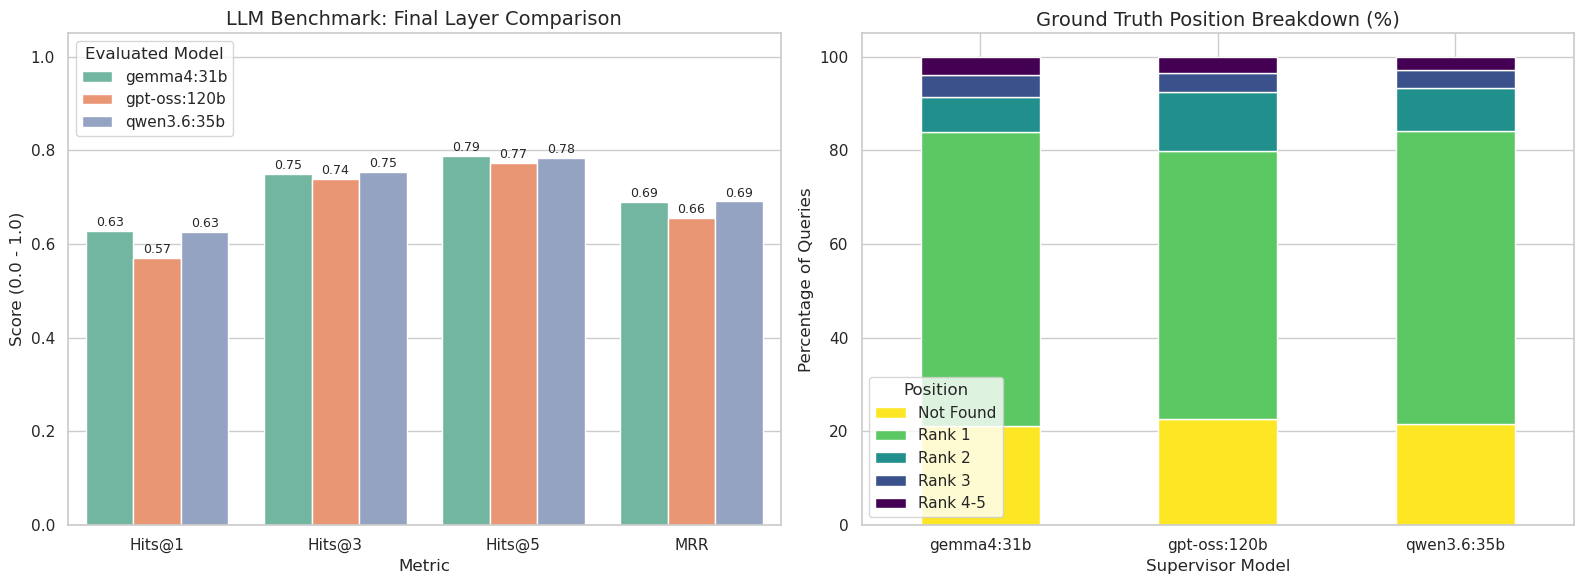

In [15]:
eval_df["calculated_rank"] = test_df.apply(
    get_true_rank, axis=1, gt_dict=gt_mapping
)
eval_df = eval_df.dropna(subset=["calculated_rank"])


# 4. Compute Metrics per Model Group
def compute_metrics(group):
    total_queries = len(group)
    if total_queries == 0:
        return pd.Series()

    h1 = (group["calculated_rank"] == 1).sum() / total_queries
    h3 = (group["calculated_rank"].isin([1, 2, 3])).sum() / total_queries
    h5 = (group["calculated_rank"].isin([1, 2, 3, 4, 5])).sum() / total_queries
    mrr = (
        group["calculated_rank"].apply(lambda r: 1 / r if r > 0 else 0).mean()
    )

    return pd.Series(
        {"Hits@1": h1, "Hits@3": h3, "Hits@5": h5, "MRR": mrr, "Total": total_queries}
    )


# Group by the 'model' column and calculate
benchmarking_results = (
    eval_df.groupby("evaluator_model").apply(compute_metrics, include_groups=False).reset_index()
)

print("=== LLM BENCHMARKING RESULTS ===")
print(benchmarking_results.to_string(index=False))

# --- STEP 5: VISUALIZATION ---

# Melt the dataframe to make it compatible with seaborn's hue (long-form data)
melted_df = benchmarking_results.melt(
    id_vars=["evaluator_model"],
    value_vars=["Hits@1", "Hits@3", "Hits@5", "MRR"],
    var_name="Metric",
    value_name="Score",
)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Grouped Bar Chart comparing all metrics across models
sns.barplot(
    x="Metric",
    y="Score",
    hue="evaluator_model",
    data=melted_df,
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("LLM Benchmark: Final Layer Comparison", fontsize=14)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Score (0.0 - 1.0)")
axes[0].legend(title="Evaluated Model", loc="upper left")

# Add value labels on top of the bars
for p in axes[0].patches:
    if p.get_height() > 0:  # Skip empty patches
        axes[0].annotate(
            f"{p.get_height():.2f}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="center",
            xytext=(0, 6),
            textcoords="offset points",
            fontsize=9,
        )

# Plot 2: Miss Rate / Breakdown Analysis
eval_df["Rank_Group"] = eval_df["calculated_rank"].apply(
    lambda r: "Not Found" if r == 0 else f"Rank {int(r)}" if r <= 3 else "Rank 4-5"
)
distribution_df = (
    eval_df.groupby(["evaluator_model", "Rank_Group"]).size().unstack(fill_value=0)
)
# Normalize to percentages for a fair comparison if query counts differ slightly
distribution_df_pct = distribution_df.div(distribution_df.sum(axis=1), axis=0) * 100

distribution_df_pct.plot(
    kind="bar", stacked=True, cmap="viridis_r", ax=axes[1]
)
axes[1].set_title("Ground Truth Position Breakdown (%)", fontsize=14)
axes[1].set_ylabel("Percentage of Queries")
axes[1].set_xlabel("Supervisor Model")
axes[1].legend(title="Position", loc="lower left")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("llm_benchmark_comparison.png", dpi=300)
plt.show()

=== LLM BENCHMARKING RESULTS ===
evaluator_model   Hits@1   Hits@3   Hits@5      MRR  Total
     gemma4:31b 0.390947 0.522634 0.543210 0.454458  243.0
    qwen3.6:35b 0.522410 0.693608 0.727039 0.606968 2722.0


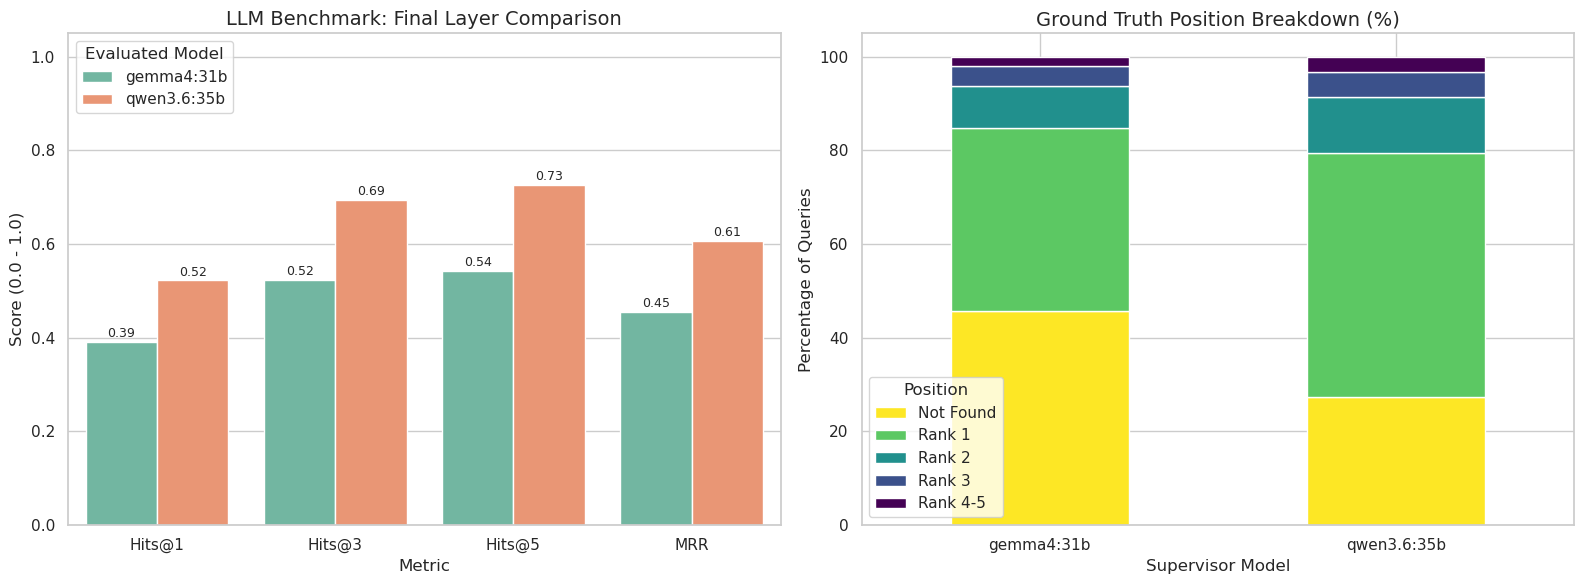

In [7]:
test_df["calculated_rank"] = test_df.apply(
    get_true_rank, axis=1, gt_dict=gt_mapping
)
test_df =test_df.dropna(subset=["calculated_rank"])


# 4. Compute Metrics per Model Group
def compute_metrics(group):
    total_queries = len(group)
    if total_queries == 0:
        return pd.Series()

    h1 = (group["calculated_rank"] == 1).sum() / total_queries
    h3 = (group["calculated_rank"].isin([1, 2, 3])).sum() / total_queries
    h5 = (group["calculated_rank"].isin([1, 2, 3, 4, 5])).sum() / total_queries
    mrr = (
        group["calculated_rank"].apply(lambda r: 1 / r if r > 0 else 0).mean()
    )

    return pd.Series(
        {"Hits@1": h1, "Hits@3": h3, "Hits@5": h5, "MRR": mrr, "Total": total_queries}
    )


# Group by the 'model' column and calculate
benchmarking_results = (
    test_df.groupby("evaluator_model").apply(compute_metrics, include_groups=False).reset_index()
)

print("=== LLM BENCHMARKING RESULTS ===")
print(benchmarking_results.to_string(index=False))

# --- STEP 5: VISUALIZATION ---

# Melt the dataframe to make it compatible with seaborn's hue (long-form data)
melted_df = benchmarking_results.melt(
    id_vars=["evaluator_model"],
    value_vars=["Hits@1", "Hits@3", "Hits@5", "MRR"],
    var_name="Metric",
    value_name="Score",
)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Grouped Bar Chart comparing all metrics across models
sns.barplot(
    x="Metric",
    y="Score",
    hue="evaluator_model",
    data=melted_df,
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("LLM Benchmark: Final Layer Comparison", fontsize=14)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Score")
axes[0].legend(title="Evaluated Model", loc="upper left")

# Add value labels on top of the bars
for p in axes[0].patches:
    if p.get_height() > 0:  # Skip empty patches
        axes[0].annotate(
            f"{p.get_height():.2f}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="center",
            xytext=(0, 6),
            textcoords="offset points",
            fontsize=9,
        )

# Plot 2: Miss Rate / Breakdown Analysis
test_df["Rank_Group"] = test_df["calculated_rank"].apply(
    lambda r: "Not Found" if r == 0 else f"Rank {int(r)}" if r <= 3 else "Rank 4-5"
)
distribution_df = (
    test_df.groupby(["evaluator_model", "Rank_Group"]).size().unstack(fill_value=0)
)
# Normalize to percentages for a fair comparison if query counts differ slightly
distribution_df_pct = distribution_df.div(distribution_df.sum(axis=1), axis=0) * 100

distribution_df_pct.plot(
    kind="bar", stacked=True, cmap="viridis_r", ax=axes[1]
)
axes[1].set_title("Ground Truth Position Breakdown (%)", fontsize=14)
axes[1].set_ylabel("Percentage of Queries")
axes[1].set_xlabel("Supervisor Model")
axes[1].legend(title="Position", loc="lower left")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("llm_benchmark_comparison.png", dpi=300)
plt.show()